**Using PINNs to find out how long it takes for a beer (or non-alcoholic, for those who prefer so :)) bottle to cool down in a fridge**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PINN_3d import *
from FFEM_building_blocks import Mesh
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

In [4]:
# Modelling the bottle as an infinitely long (not true, but whatever, I want to stick to 2 spatial dimensions) cylinder of radius R
# the bottle is originally at 22 degrees
# It sits in the fridge with no convective heat trasnfer, just constant temperature at the boundary (4 C)
# Goal: understand when the average temperature of the bottle cools down to a target temperature (say 6 C)
# simple heat equation with Dirichlet boundary conditions, no recirculations inside the bottle

bottle_radius = 0.02
target_temperature = 6
alpha_water = 0.133e-6 #m2/s thermal diffusivity of water

#strategy: solve for alpha = 1. then rescale t -> t / alpha_water in the solution
bottle_pinn = PINN_heat_2d_circle(N_internal_nodes=16, f_initial=lambda x: 22, f_dirichlet=lambda x: 4, R=bottle_radius, t_bounds=(0,1), alpha = 1)
bottle_pinn.set_collocation_points(3000)
bottle_pinn.compute_initial_values(1000, 0)
bottle_pinn.compute_boundary_values(1000)
bottle_pinn.compute_physics_loss()

bottle_pinn.train_RAD()

Epoch [1000/30000], N_collocation_points: 3300, Loss: 15.5267
Epoch [2000/30000], N_collocation_points: 3700, Loss: 13.7375
Epoch [3000/30000], N_collocation_points: 4100, Loss: 16.6550
Epoch [4000/30000], N_collocation_points: 4500, Loss: 16.1421
Epoch [5000/30000], N_collocation_points: 4900, Loss: 16.3278
Epoch [6000/30000], N_collocation_points: 5300, Loss: 16.7701
Epoch [7000/30000], N_collocation_points: 5700, Loss: 21.8315
Epoch [8000/30000], N_collocation_points: 6100, Loss: 16.9495
Epoch [9000/30000], N_collocation_points: 6500, Loss: 16.1653
Epoch [10000/30000], N_collocation_points: 6900, Loss: 23.1277
Epoch [11000/30000], N_collocation_points: 7300, Loss: 20.3731
Epoch [12000/30000], N_collocation_points: 7700, Loss: 14.2732
Epoch [13000/30000], N_collocation_points: 8100, Loss: 35.6535
Epoch [14000/30000], N_collocation_points: 8500, Loss: 8.8509
Epoch [15000/30000], N_collocation_points: 8900, Loss: 14.1640
Epoch [16000/30000], N_collocation_points: 9300, Loss: 13.9471
Ep

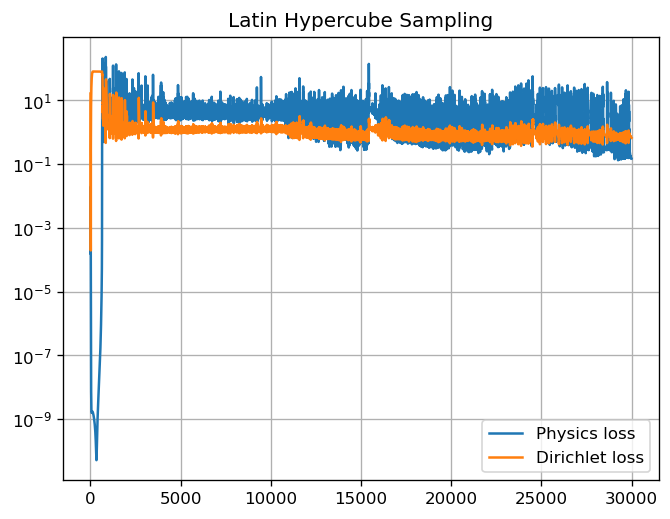

In [7]:

plt.figure(dpi= 120)
plt.title('Latin Hypercube Sampling')
plt.semilogy(bottle_pinn.physics_losses, label = "Physics loss")
plt.semilogy(bottle_pinn.dirichlet_losses, label = "Dirichlet loss")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# test to plot functions on a circle

def f(x, y, t):
    coords = torch.tensor([x,y,t], dtype=torch.float32)
    with torch.no_grad():
        u_pred = bottle_pinn.model(coords)  # shape (20000, 1)
    return u_pred

print(f(0.01,0.01,0.01))


#TO DO: FIX AND FINISH
res = u_pred.numpy().reshape(len(y), len(x))  # back to (100, 200) to match X, Y grid
radius = 1.0
N_r, N_theta = 200, 200

r = np.linspace(0, radius, N_r)
theta = np.linspace(0, 2*np.pi, N_theta)
R, Theta = np.meshgrid(r, theta)

X = R * np.cos(Theta)
Y = R * np.sin(Theta)
Z = f(X, Y)

fig, ax = plt.subplots(figsize=(6, 6))
pcm = ax.pcolormesh(X, Y, Z, shading='auto', cmap='viridis')
ax.set_aspect('equal')
fig.colorbar(pcm, ax=ax, label='f(x, y)')
ax.set_title('Function on a disk')
plt.show()

tensor([4.8990])


NameError: name 'u_pred' is not defined